In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from scipy.io import loadmat
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from scipy.interpolate import RegularGridInterpolator

# Import Data

In [2]:
data = {
    "date": [
        "19920907","19920908","19920909","19920910","19920910",
        "19920911","19920911","19920911","19920911","19920912"
    ],
    "time": [
        "170000","230000","170000","050000","230000",
        "110000","150000","170000","230000","170000"
    ],
    "long": [
        -145.0,-151.9,-156.1,-158.5,-159.8,
        -160.0,-159.7,-159.5,-159.1,-158.4
    ],
    "lat": [
        12.2,13.1,13.7,15.1,17.6,
        20.0,21.6,22.6,24.6,31.4
    ],
    "central_pressure_kpa": [
        100.2,99.2,98.0,96.0,94.7,
        94.0,94.5,94.5,96.0,99.0
    ],
    "max_wind_speed_mph": [
        40,75,100,115,130,
        145,130,130,115,75
    ]
}

df = pd.DataFrame(data)

In [3]:
#make datetime column
df["datetime_hst"] = pd.to_datetime(df["date"] + df["time"], format="%Y%m%d%H%M%S")

In [4]:
data = {
    "time_hst": [
        "000000","030000","060000","090000",
        "120000","150000","180000","210000"
    ],
    "water_level_ft": [
        2.3,1.8,0.8,1.1,
        1.8,1.6,1.0,1.5
    ]
}

tides = pd.DataFrame(data)

#make datetime column
tides["time_hst"] = pd.to_datetime(tides["time_hst"], format="%H%M%S").dt.time

# 1)

In [5]:
#make geodataframe
geometry = [Point(xy) for xy in zip(df.long, df.lat)]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
#gdf

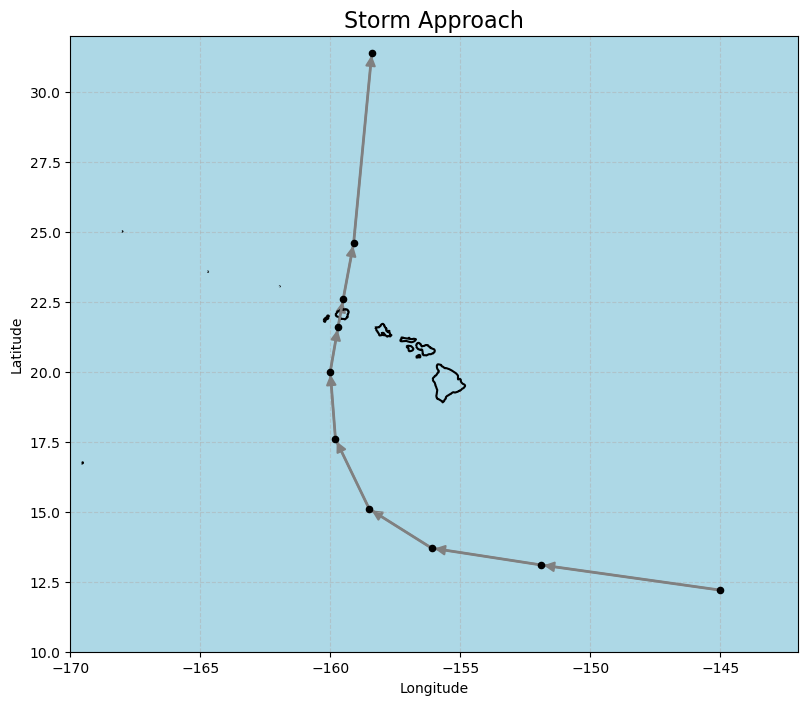

In [6]:
#plot
world = gpd.read_file("ne_10m_coastline")
line = LineString(gdf.geometry.tolist())
track_gdf = gpd.GeoDataFrame(geometry=[line], crs=gdf.crs)

fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color='black')
track_gdf.plot(ax=ax, color='grey', linewidth=2)
gdf.plot(ax=ax, color='black', markersize=20, zorder=5)
#arrow code
for i in range(len(gdf)-1):
    x_start, y_start = gdf.geometry.iloc[i].x, gdf.geometry.iloc[i].y
    x_end, y_end = gdf.geometry.iloc[i+1].x, gdf.geometry.iloc[i+1].y
    arrow = FancyArrowPatch(
        (x_start, y_start), (x_end, y_end),
        arrowstyle='-|>', color='grey', mutation_scale=15, linewidth=1.5
    )
    ax.add_patch(arrow)

ax.set_xlim(-170, -142)
ax.set_ylim(10, 32)

ax.set_title("Storm Approach", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_facecolor("lightblue")
ax.grid(True, linestyle='--', alpha=0.5)
#plt.savefig('Storm_Approach.jpg')
plt.show()

In [59]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2

    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


In [8]:
# Shift latitude and longitude to get previous point
df['lat_prev'] = df['lat'].shift(1)
df['long_prev'] = df['long'].shift(1)
df['time_prev'] = df['datetime_hst'].shift(1)

# Calculate distance (km) between points
df['distance_km'] = df.apply(
    lambda row: haversine(row['lat_prev'], row['long_prev'], row['lat'], row['long'])
                if pd.notnull(row['lat_prev']) else 0,
    axis=1
)
df['time_diff_hours'] = (df['datetime_hst'] - df['time_prev']).dt.total_seconds() / 3600
df['vel (km/hr)'] = df['distance_km'] / df['time_diff_hours']
df['vel (m/s)'] = (df['distance_km'] * 1000) / (df['time_diff_hours'] * 3600)
df.drop(columns=['lat_prev','long_prev','time_prev','time_diff_hours'], inplace=True)

In [9]:
#Values for table
pd.DataFrame({'datetime_hst': df['datetime_hst'], 'vel (m/s)': df['vel (m/s)']})

,datetime_hst,vel (m/s)
0,1992-09-07 17:00:00,NaN
1,1992-09-08 23:00:00,6.993056
2,1992-09-09 17:00:00,7.085948
3,1992-09-10 05:00:00,6.984578
4,1992-09-10 23:00:00,4.794216
5,1992-09-11 11:00:00,6.196684
6,1992-09-11 15:00:00,12.543330
7,1992-09-11 17:00:00,15.706647
8,1992-09-11 23:00:00,10.467284
9,1992-09-12 17:00:00,11.716599


# 2)

In [10]:
#Get shape factor by converting from kpa to hpa then using equation
df['B'] = 2 - (((df['central_pressure_kpa']* 10) - 900) / 160)

In [11]:
B = df['B'].mean()
B

np.float64(1.5868749999999998)

# 3)

In [47]:
#load given bathymetric data
bdata = loadmat('kauai_01s.mat')
#turn into arrays
#lat
x = bdata['x']
#long
y = bdata['y']
#elevation/water depth
z = bdata['z']

# Flatten arrays
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()

lat_line.shape

(200,)

In [13]:
#df_bath

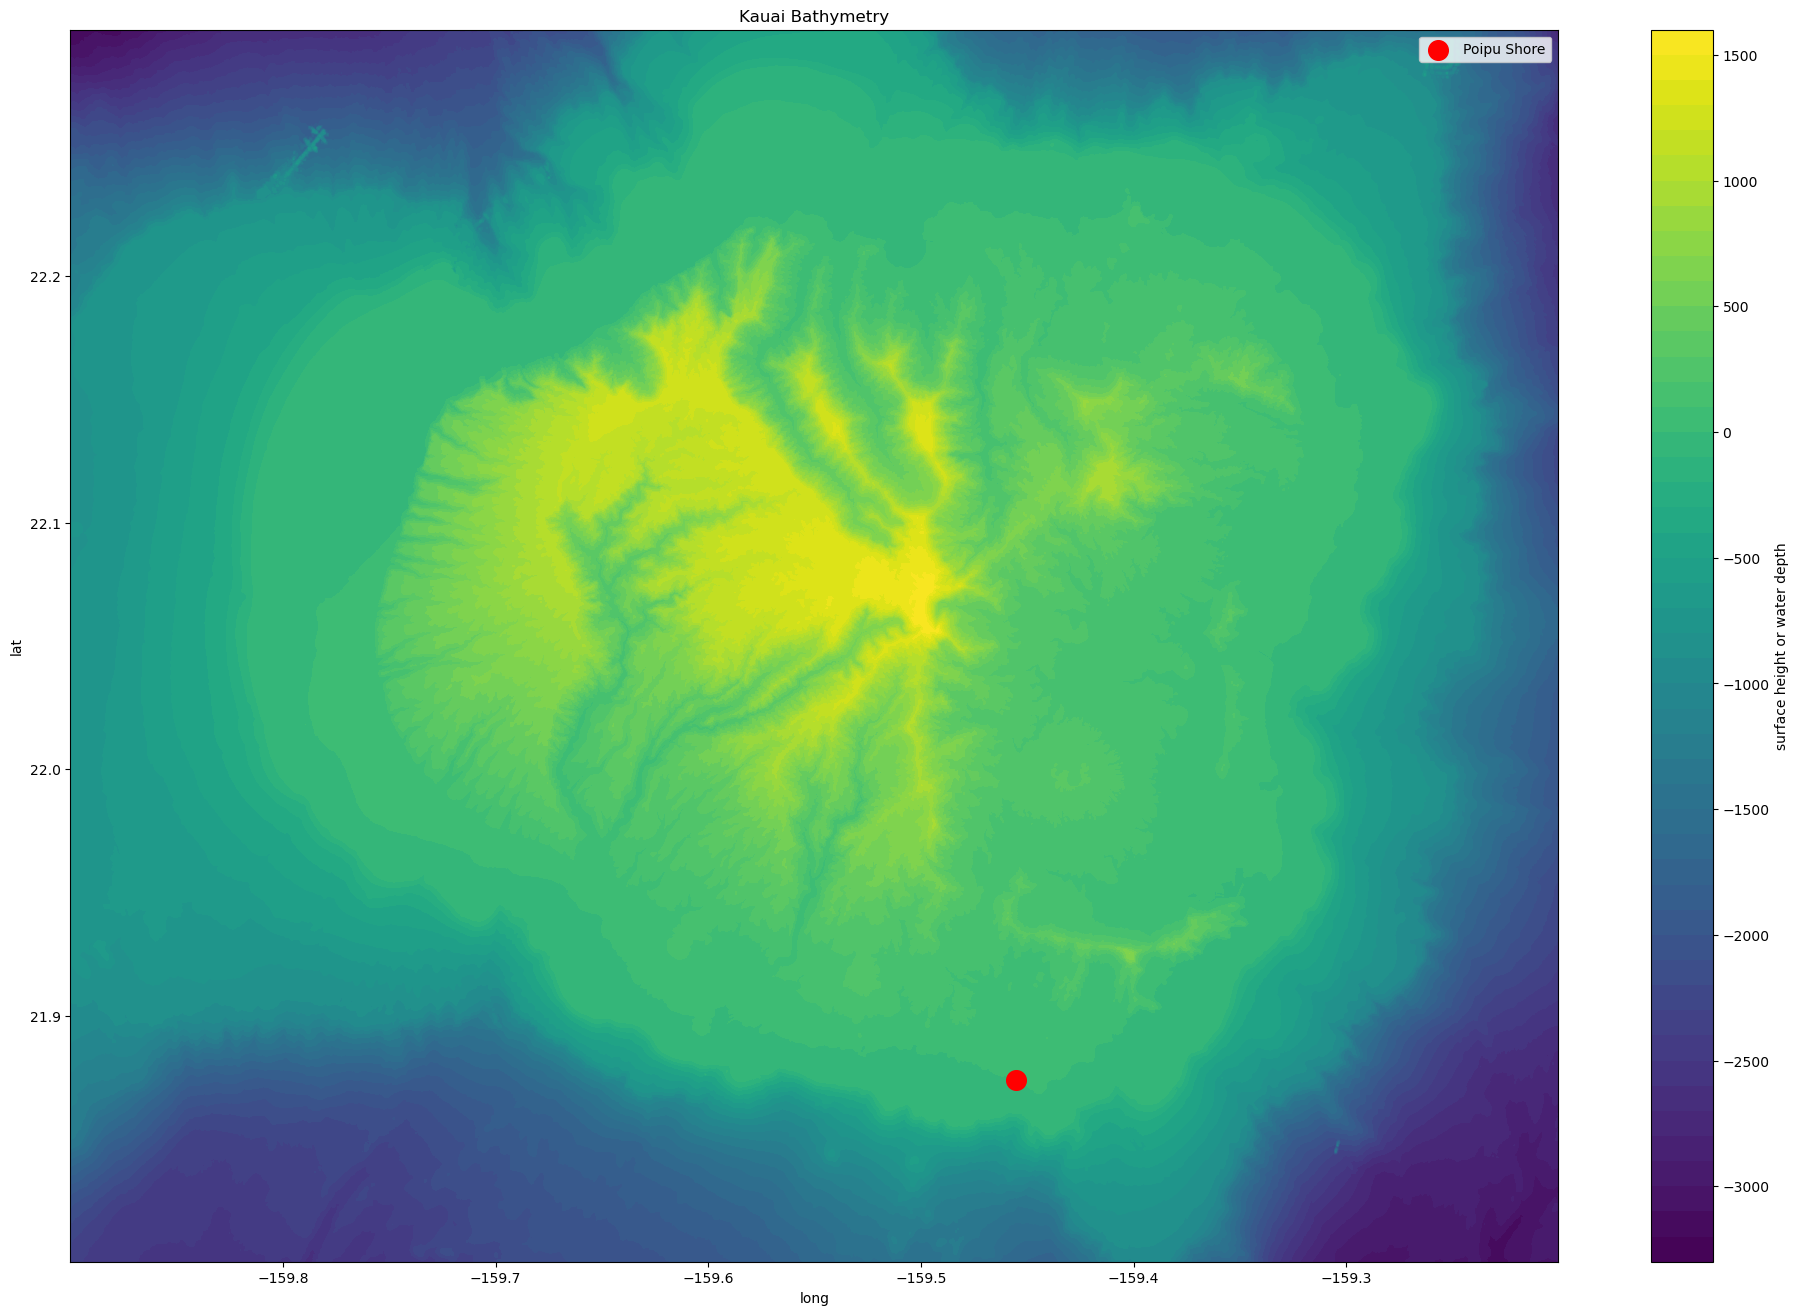

In [14]:
plt.figure(figsize=(24, 16))
plt.contourf(x, y, z, levels=50, cmap='viridis')
plt.colorbar(label='surface height or water depth')
plt.scatter(-159.455107, 21.87398, color='red', s=200, label='Poipu Shore')
plt.xlabel('long')
plt.ylabel('lat')
plt.title('Kauai Bathymetry')
plt.legend()
plt.show()

In [15]:
#subset bounds
lat_min, lat_max = 21.8, 22.0
lon_min, lon_max = -159.55, -159.35

#filter indices by values 
lat_idx = np.where((y[:,0] >= lat_min) & (y[:,0] <= lat_max))[0]
lon_idx = np.where((x[0,:] >= lon_min) & (x[0,:] <= lon_max))[0]

#pull subset
x_subset = x[np.ix_(lat_idx, lon_idx)]
y_subset = y[np.ix_(lat_idx, lon_idx)]
z_subset = z[np.ix_(lat_idx, lon_idx)]


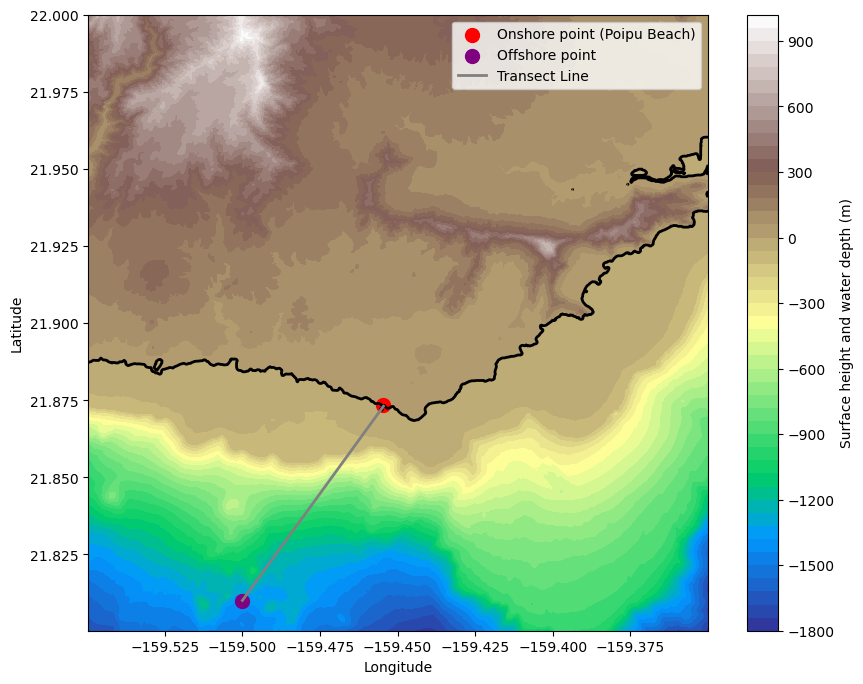

In [150]:
#Poipu and line points
lon_points = np.array([-159.435, -159.45456, -159.5, -159.55898943886064])
lat_points = np.array([21.9, 21.87333, 21.81, 21.728379188279384])

plt.figure(figsize=(10, 8))
#Bathymetric data
cf = plt.contourf(x_subset, y_subset, z_subset, levels=50, cmap='terrain')
#plt.scatter(lon_points[0], lat_points[0], color='blue', s=100, label='Onshore point (Poipu Beach)')
plt.scatter(lon_points[1], lat_points[1], color='red', s=100, label='Onshore point (Poipu Beach)')
plt.scatter(lon_points[2], lat_points[2], color='purple', s=100, label='Offshore point')
shoreline = plt.contour(x_subset, y_subset, z_subset,levels=[0], colors='black', linewidths=2)

#Line through all
slope, intercept = np.polyfit(lon_points, lat_points, 1)
lon_line = np.linspace(lon_points[1], -159.50, 200)
lat_line = slope * lon_line + intercept
plt.plot(lon_line, lat_line, color='grey', linewidth=2, label='Transect Line')

plt.colorbar(cf, label='Surface height and water depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.savefig('Transect Profile.jpg')
plt.show()

In [51]:
#Get coordinate axis
lon = x[0, :]
lat = y[:, 0]

#Make interpolator
interp = RegularGridInterpolator((lat, lon),z, bounds_error=False, fill_value=np.nan)

#Turn them into points that can be interpolated
points = np.column_stack((lat_line, lon_line))
#Interpolate
z_line = interp(points)

In [60]:
#Initialize distance 
dist = np.zeros(len(lat_line))

#get end points
lat1 = lat_line[:-1]
lon1 = lon_line[:-1]
lat2 = lat_line[1:]
lon2 = lon_line[1:]

#find the change in distance
segment_lengths = haversine(lat1, lon1, lat2, lon2)
#Sum to find total distance
dist[1:] = np.cumsum(segment_lengths)

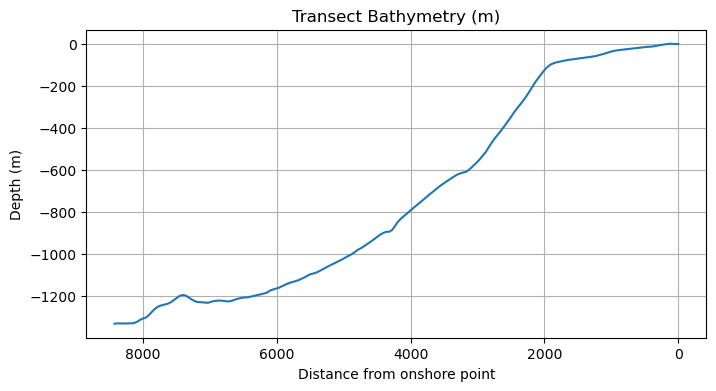

In [65]:
plt.figure(figsize=(8,4))
plt.plot(dist, z_line)
plt.gca().invert_xaxis()
plt.xlabel("Distance from onshore point")
plt.ylabel("Depth (m)")
plt.title("Transect Bathymetry (m)")
plt.grid()
plt.savefig('Transect Plan View.jpg')
plt.show()

# 4)

In [68]:
#constants
Omega = 7.2921159e-5 #s^-1
rho_a = 1.15 #kg/m^3

phi_deg = 21.81 #lat
delta_P = (101.3 - 94.5) * 1000 #P_amb - P @ center of storm at critical time (Pa)

Rmw_km = 23 #km
r_km = 23 #km
Km = 0.80 # Given
V_f_mps = 12.543 # storm forward speed (m/s, ~10 kt)

'''
conversions
'''
phi = np.radians(phi_deg)
Rmw = Rmw_km * 1000        # km → m
r = r_km * 1000            # km → m

In [73]:
#coriolis
f = 2 * Omega * np.sin(phi)

#Vg
term_pressure = (B * delta_P / rho_a) * (Rmw / r)**B * np.exp(-(Rmw / r)**B)
term_coriolis = (r * f / 2)**2

Vg = np.sqrt(term_pressure + term_coriolis) - (r * f / 2)


#V10
V10 = Km * Vg

#Ur
Ur = V10 + 0.5 * V_f_mps

#convert from m/s to mph
def ms_to_mph(v):
    return v * 2.23694

print("------ RESULTS ------")
print(f"Latitude : {phi_deg}°")
print(f"Coriolis: {f:.5e} s^-1")
print(f"Vg: {Vg:.2f} m/s ({ms_to_mph(Vg):.1f} mph)")
print(f"V10: {V10:.2f} m/s ({ms_to_mph(V10):.1f} mph)")
print(f"Ur: {Ur:.2f} m/s ({ms_to_mph(Ur):.1f} mph)")

------ RESULTS ------
Latitude : 21.81°
Coriolis: 5.41848e-05 s^-1
Vg: 58.13 m/s (130.0 mph)
V10: 46.51 m/s (104.0 mph)
Ur: 52.78 m/s (118.1 mph)


In [ ]:
#Storm center
lon_center = -159.7
lat_center = 21.6

#Offshore point
lon_point = -159.95
lat_point = 21.81

# Storm forward motion vector (toward)
V_f_mps = 12.543          # m/s
theta_f_deg = 45.0        # degrees FROM north, 0 = north, clockwise

# Convert to radians
lon_c = np.radians(lon_center)
lat_c = np.radians(lat_center)
lon_p = np.radians(lon_point)
lat_p = np.radians(lat_point)

In [ ]:
#Convert to cartesian
dx = (lon_p - lon_c) * np.cos((lat_c + lat_p)/2) * 6371000  # meters
dy = (lat_p - lat_c) * 6371000                               # meters

#Get angle (in radians)
azimuth_rad = np.arctan2(dx, dy)
#rotate CCW for the NH, so add 90 deg
Vg_dir_rad = azimuth_rad + np.pi/2

In [78]:
#add V_F
theta_f_rad = np.radians(theta_f_deg)
Vf_x = 0.5 * V_f_mps * np.sin(theta_f_rad)
Vf_y = 0.5 * V_f_mps * np.cos(theta_f_rad)

#Decompose into x and y
Vg_x = np.sin(Vg_dir_rad)
Vg_y = np.cos(Vg_dir_rad)
U_x = Vg_x + Vf_x
U_y = Vg_y + Vf_y

#Get final vector
wind_dir_rad = np.arctan2(U_x, U_y)
wind_dir_deg = (np.degrees(wind_dir_rad)) % 360  # ensure 0–360°

print("------ RESULTS ------")
print(f"Radial azimuth: {np.degrees(azimuth_rad):.1f}°")
print(f"Vg direction: {np.degrees(Vg_dir_rad)%360:.1f}°")
print(f"Final Angle: {wind_dir_deg:.1f}° (from north)")

------ RESULTS ------
Radial azimuth: -47.9°
Vg direction: 42.1°
Final Angle: 44.6° (from north)


# 5)

In [86]:
delta_P_hPa = (1013 - 945)  #Pa to hPa
alpha = 1.0
Rmw_km = Rmw / 1000 #m to km

#Hs
Hs = 5.03 * np.exp(Rmw_km * delta_P_hPa / 4700) * (1 + 0.29 * alpha * V_f_mps / np.sqrt(Ur))
#Tp
Ts = 8.6 * np.exp(Rmw_km * delta_P_hPa / 9400) * (1 + 0.145 * alpha * V_f_mps / np.sqrt(Ur))

print("------ RESULTS ------")
print(f"Significant wave height Hs: {Hs:.2f} m")
print(f"Significant wave period Ts: {Ts:.2f} s")

------ RESULTS ------
Significant wave height Hs: 10.53 m
Significant wave period Ts: 12.70 s


In [95]:
lon_offshore = -159.5
lat_offshore = 21.81

#Vector from storm to offshore
dx_wave = (lon_offshore - lon_center) * np.cos(np.radians((lat_center + lat_offshore)/2)) * 6371000
dy_wave = (lat_offshore - lat_center) * 6371000
#Azimuth
radial_azimuth = np.arctan2(dx_wave, dy_wave)

#rotate 90 deg
wave_dir_rad = radial_azimuth - np.pi/2
wave_dir_deg = (np.degrees(wave_dir_rad)) % 360
print(f"Approximate wave propagation direction: {wave_dir_deg:.1f} (from north, clockwise)")

Approximate wave propagation direction: 311.5 (from north, clockwise)


# 6)

In [97]:
Hs = 10.53 #m
Tp = 12.7 #s
g = 9.81 #m/s^2

Hrms = Hs / np.sqrt(2)
L = (g * Ts**2) / (2 * np.pi)
ratio = Hrms/L

setup = 0.15 * Hrms
print(f"Ratio for using CEM plot: {ratio:.3f}")
print(f"Worst case Setup: {setup:.2f} m")

Ratio for using CEM plot: 0.030
Worst case Setup: 1.12 m


In [122]:
rho = 1026 #kg/m^3
#setup
r_tides = 23000 #m
zeta = (delta_P / (rho * g)) * (1 - np.exp(-(Rmw / r_tides)**B))

print(f"Barometric setup: {zeta:.3f} m")

Barometric setup: 0.427 m


In [139]:
K = 1.1 * (1.21e-6 + 2.25e-6 * (1 - (5.6 / Ur))**2)
#K

In [142]:
#initalize output
surge = np.zeros_like(dist)

#Run for entire length of transect
for i in range(1, len(dist)):
    #distance between points
    dx = dist[i] - dist[i - 1]
    #depth
    d = z_line[i]
    
    #code to avoiding dividing by 0
    if d <= 0:
        surge[i] = surge[i-1]
        continue
    
    #from the equation
    delta_s = d * ( np.sqrt(1 + (2 * K * Ur**2 * dx) / (g * d**2)) - 1 )  
    #sum all of the values cumulatively
    surge[i] = surge[i - 1] + delta_s

In [146]:
#Final value is the total surge:
wind_surge = surge[-1]
print(f"Wind Surge: {wind_surge:.2f} m")

Wind Surge: 0.10 m


In [148]:
a_tides = 1.6 * 0.3048
DWL = setup + zeta + wind_surge + a_tides
print(f"DWL: {DWL:.2f} m")

DWL: 2.13 m


# 7)

In [169]:
#Based off of the plot we approximate the slope to be 0.033
m_land = 0.033
r_factor = 0.9
runup = r_factor * Ts* np.sqrt(g * Hs) * m_land
runup #m

np.float64(3.8334823574930015)

In [173]:
inundation = runup/m_land
print(f"Inundation: {inundation:.1f} m")

Inundation: 116.2 m
